# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abuhussein1504/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

---

**Question:** out of a large content portfolio, which pages should a human reviewer look at
first this cycle?

**Decision it supports:** a FlyRank content strategist / editor has a fixed monthly review
budget — **K = 50 pages** (fixed in `w02_ml_task_framing.ipynb`, before any model was trained,
and used as the metric's K everywhere in this project). The output of this notebook is a
ranked, reason-coded queue of which 50 pages to open first.

**Cost of a wrong call:** a false positive (flagging a healthy page) wastes ~10-15 minutes of
review; a false negative (missing a real decline) lets it run unnoticed for another cycle — an
asymmetric cost that favors reviewing over staying silent (`w01_research_question.ipynb`).

**Why ML, not just the existing rule:** FlyRank's product flags are fixed thresholds on one or
two signals. This project's own signal audit found the most obvious one — staleness — is a
**MIXED** predictor of decline on its own (`w04_baseline_score.ipynb`): decline rate rises
through the 91-180 day freshness tier, then *drops* at 181+ days. A model that weighs several
signals jointly is positioned to close that gap.


In [1]:
# This notebook mirrors the deployed paper (docs/index.html) and the source
# write-up (work/capstone_report.md). Every table/number below is loaded from the committed
# receipts in work/outputs/ and work/figures/ -- produced by w04-w07, not recomputed here --
# so this notebook reruns instantly and never re-fits a model just to render the paper.
import os, sys, subprocess, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

REPO_URL = "https://github.com/abuhussein1504/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

# Same pattern as w01-w07: if we are not already sitting at the repo root (e.g. a fresh
# Colab runtime), clone it and cd in. If run locally from a checkout, this is a no-op.
if not Path("work/outputs").exists():
    if not Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

OUT = Path("work/outputs")
FIG = Path("work/figures")
assert OUT.exists(), "Still not at the repo root -- check the clone/cwd above."

K = 50
print(f"Review budget K = {K} pages/cycle -- fixed in w02_ml_task_framing.ipynb, used throughout.")


Review budget K = 50 pages/cycle -- fixed in w02_ml_task_framing.ipynb, used throughout.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

---

**Working dataset:** `data/raw/content_refresh_anonymized.csv` -- 30,000 rows, 44 columns, one
row per pseudonymized content page, trailing-90-day snapshot, 32 clients. The baseline, model,
validation, and action queue below are all built and measured on this file.

**Warehouse rehearsal (kept separate on purpose):** a data contract was verified against the
March 2026 partition of `FlyRank/internship-warehouse` on Hugging Face --
**9,841,378 rows, 331,437 content items, 55 clients, 2026-03-01 to 2026-03-31** -- a slice of
the full ~78.8M-row release (`w03_data_contract.ipynb`). It proves the same grain/field/leakage
discipline holds at production scale, but it did **not** feed the model in Section 4. Keeping
this separate avoids ever implying the headline numbers below come from 79M rows when they
come from the 30k-row starter export.

**Excluded, and why:** `avg_position = 0` (means "no data," not rank zero) -- rows with
`impression_tier == "no_data"` (no real impression reading) -- `content_id` / `client_id`
(pseudonymous, grouping only) -- `trend_direction` / `trend_pct` (the label's own source,
predicted, never a feature) -- `ga4_*` columns before a client's `ga4_data_start` (zero-filled
placeholders in the warehouse table, not real zero-engagement days).

**Eligible population:** 28,795 of 30,000 pages (96.0%) have real ranking + impression signal.
Every metric in this notebook is computed against that population. No client name, domain,
URL, title, or keyword appears anywhere in `work/`.


In [2]:
import pandas as pd

CSV = Path("data/raw/content_refresh_anonymized.csv")
df = pd.read_csv(CSV)
eligible_mask = (df["impression_tier"] != "no_data") & (df["avg_position"] > 0)
elig = df.loc[eligible_mask]

print(f"rows total: {len(df):,}")
print(f"eligible population: {len(elig):,}  ({len(elig)/len(df):.1%} of total)")
print(f"distinct clients (eligible slice): {elig['client_id'].nunique()}")
print(f"base rate (is_declining = trend_direction == 'down'): "
      f"{(elig['trend_direction'] == 'down').mean():.3f}")


rows total: 30,000
eligible population: 28,795  (96.0% of total)
distinct clients (eligible slice): 31
base rate (is_declining = trend_direction == 'down'): 0.564


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

---

**Target:** `is_declining` = (`trend_direction == "down"`) -- an *observed* column in the
export, not a rule this analysis defined itself.

**Baseline (`w04_baseline_score.ipynb`):** `stale_but_visible` flags a page when
`days_since_last_update >= 90` **and** `impressions_90d >= 500`, scored by raw
`impressions_90d` among flagged pages, zero otherwise. No fitted weights -- every flagged page
carries a reason a reviewer can check by hand.

**Features (`w05_model.ipynb`, post-leakage-removal):** trailing-90/30-day engagement and
search columns, missingness flags computed *before* filling blanks (missingness follows
`content_type`, not randomness), one-hot `content_type` / `main_intent`. `content_id` /
`client_id` never enter the feature matrix.

**The leakage catch:** an early feature list included `impressions_last_30d` and
`impressions_prev_30d`. Precision@50 hit a suspicious **1.000**. The attack test confirmed why:
`corr((last - prev) / prev, trend_pct) = 0.99999998` -- those columns are `trend_pct`'s own
source columns. Both removed; a second check injecting `trend_pct` directly confirmed the
leak-detector is actually sensitive (score jumped back to 1.000).

**Validation (`w06_validation_audit.ipynb`):** `GroupKFold` by `client_id`, 5 folds, across the
31 distinct clients in the eligible slice -- every fold tests on clients never trained on. No
time-based split exists: the starter export is one trailing-90-day snapshot, not a daily panel
-- a real data limitation, named rather than hidden.

**Models:** Logistic Regression, then Random Forest (readable first, stronger second per the
project's method-selection rule), scored by predicted probability, ranked, evaluated at
Precision@50 against the identical eligible population, split, and K as the baseline.


In [3]:
with open(OUT / "w05_model_metrics.json") as f:
    m5 = json.load(f)
with open(OUT / "w06_validation_audit.json") as f:
    m6 = json.load(f)

print("Leakage catch (w05):")
print(json.dumps(m5["leakage_check"], indent=2))

print("\nLeak-detector sanity check (w06, trend_pct injected directly):")
print(json.dumps(m6["leak_detector_sanity_check"], indent=2))


Leakage catch (w05):
{
  "suspect_columns": [
    "impressions_last_30d",
    "impressions_prev_30d"
  ],
  "precision_at_k_with_leak": 1.0,
  "precision_at_k_without_leak": 0.72,
  "reason": "corr((last-prev)/prev, trend_pct) = 0.99999998 -- source columns of the label"
}

Leak-detector sanity check (w06, trend_pct injected directly):
{
  "precision_at_k_with_injected_trend_pct": 1.0,
  "note": "confirms the leakage test is sensitive; trend_pct is NOT a real feature, it's the label source"
}


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

---

The rule scores *below* the base rate -- it ranks by raw visibility, not anything
decline-shaped, exactly what the signal audit's MIXED verdict on staleness predicted. Random
Forest lands close to the base rate too: added complexity did not buy more precision on this
feature set, reported here as a finding rather than tuned away.

**How much of "0.72" is the split?** Same model, features, and K -- only the split unit
changes. A naive, non-grouped row split reports 0.860 because ~30.6 of 31 clients appear on
both sides of every fold; the honest client-grouped split reports 0.720. The 0.14-point gap is
reported as a result in its own right.


,method,precision_at_50
0,Base rate (random),0.564
1,Week-4 rule (stale_but_visible),0.440
2,Logistic Regression (client-grouped),0.720
3,Random Forest (client-grouped),0.520



Split sensitivity, same model/features/K:
  naive random split : 0.860
  client-grouped      : 0.720
  gap from split choice alone: 0.140


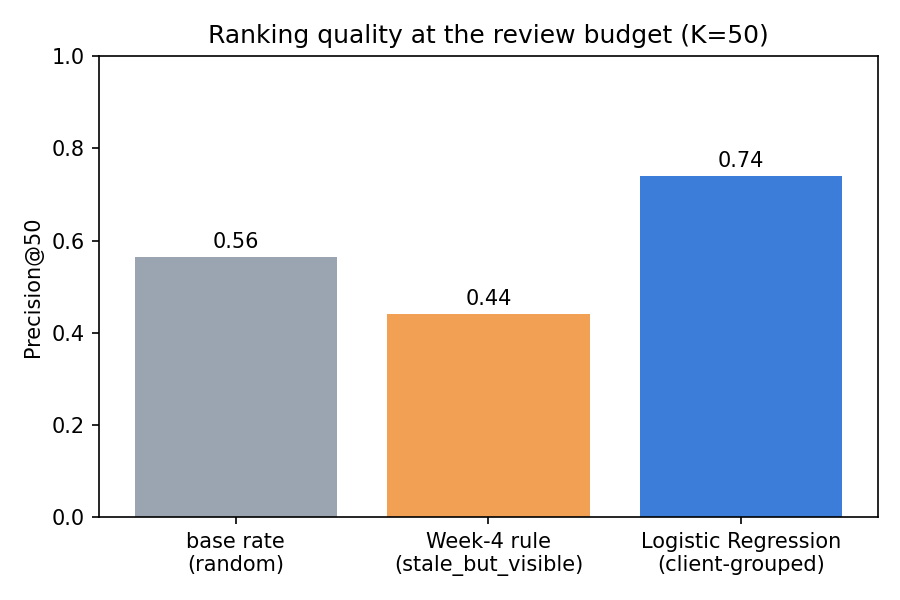

In [4]:
with open(OUT / "w04_baseline_metrics.json") as f:
    m4 = json.load(f)

# Build the comparison table directly from the committed receipts (no re-fitting).
table = pd.DataFrame([
    {"method": "Base rate (random)",                 "precision_at_50": m6["base_rate"]},
    {"method": "Week-4 rule (stale_but_visible)",     "precision_at_50": m5["precision_at_k"]["week4_baseline_rule"]},
    {"method": "Logistic Regression (client-grouped)","precision_at_50": m6["precision_at_k"]["logistic_regression_grouped_honest"]},
    {"method": "Random Forest (client-grouped)",      "precision_at_50": m5["precision_at_k"]["random_forest"]},
])
display(table)

print(f"\nSplit sensitivity, same model/features/K:")
print(f"  naive random split : {m6['precision_at_k']['logistic_regression_naive_random_split']:.3f}")
print(f"  client-grouped      : {m6['precision_at_k']['logistic_regression_grouped_honest']:.3f}")
print(f"  gap from split choice alone: "
      f"{m6['precision_at_k']['logistic_regression_naive_random_split'] - m6['precision_at_k']['logistic_regression_grouped_honest']:.3f}")

display(Image(filename=str(FIG / "w07_precision_at_k.png")))


## 5. Limitations

*What this work cannot claim.*

---

- **Cross-sectional, one snapshot.** No page was actually refreshed and re-measured -- nothing
  here shows refreshing a flagged page *will* reverse its decline. That needs an experiment
  this project does not run.
- **Narrow client coverage.** Generalization is demonstrated only across the 31 clients in this
  pseudonymized slice. A new client or vertical is untested.
- **No forward-in-time test yet.** Validation is client-held-out on one period, not a test
  against a future period -- the monitoring plan in Section 6 exists because this gap isn't
  closed.
- **The inflated number is the one that travels.** 0.860 (naive split) is easy to misquote
  without naming the split; 0.720 (client-grouped) is the number this paper defends.
- **A retrospective check, not a live one.** Using `trend_direction` only as a one-time audit
  of this historical snapshot: ~30% of `refresh_priority_review` and ~24% of
  `investigate_quiet_risk` pages were already trending up/stable. The queue orders review --
  it doesn't replace a human's judgment on any single page.
- **The warehouse rehearsal is not this model.** The 9.84M-row data-contract exercise used a
  different, re-derived proxy label and grain; it is not comparable to the numbers above.

**Not claimed:** causation, "predicting Google's algorithm," a per-client guarantee, or
forward-in-time performance.


In [5]:
with open(OUT / "w07_playbook_metrics.json") as f:
    m7 = json.load(f)

print("Retrospective audit (trend_direction used only as a one-time historical check -- never a live input):")
print(json.dumps(m7.get("retrospective_audit", m7), indent=2)[:800])


Retrospective audit (trend_direction used only as a one-time historical check -- never a live input):
{
  "k": 50,
  "base_rate": 0.564,
  "precision_at_k": {
    "week4_baseline_rule": 0.44,
    "logistic_regression_grouped_honest": 0.74
  },
  "eligible_population": 28795,
  "distinct_clients": 31,
  "action_mix": {
    "monitor": 16291,
    "investigate_quiet_risk": 3989,
    "refresh_review_routine": 3740,
    "refresh_priority_review": 2761,
    "monitor_not_owned": 1366,
    "monitor_too_new": 478,
    "verify_before_action": 170
  },
  "archetype_action_counts": {
    "comparison article": {
      "investigate_quiet_risk": 211,
      "monitor": 484,
      "monitor_not_owned": 0,
      "monitor_too_new": 0,
      "refresh_priority_review": 0,
      "refresh_review_routine": 0,
      "verify_before_action": 2
    },
    "feedly article": {
      "investigate_quiet_risk": 0,
      "mon


## 6. Ranked recommendations

*The action playbook output -- the paper's recommendations section.*

---

Priority sequence (first match wins), computed across all 28,795 eligible pages
(`w07_action_playbook.ipynb`):

| # | Action | Pages | Why |
|---|---|---:|---|
| 1 | `refresh_priority_review` | 2,761 | rule and model agree -- strongest, most auditable case |
| 2 | `investigate_quiet_risk` | 3,989 | model flags risk, rule doesn't -- the rule's blind spot |
| 3 | `refresh_review_routine` | 3,740 | rule flags it, model doesn't confirm elevated risk |
| 4 | `verify_before_action` | 170 | >=500% swing in the label's own source columns -- confirm first |
| 5 | `monitor_too_new` / `monitor_not_owned` | 478 / 1,366 | no-go: too little history, or not owned |
| 6 | `monitor` | 16,291 | no elevated signal from either rule or model this cycle |

**Before acting on any item:** check for a seasonal/one-off event, drifted search intent, a
client-side publishing change, or (for navigational-intent pages) a structurally low CTR that
isn't a content problem.

**Monitoring policy:** recompute Precision@50 for rule/model/base rate every labeled period; if
the model falls below the frozen rule for two consecutive periods, revert to the rule and
escalate for retraining review -- proposed here since this single-snapshot dataset has no
second labeled period yet to test the policy against.


,0
monitor,16291
investigate_quiet_risk,3989
refresh_review_routine,3740
refresh_priority_review,2761
monitor_not_owned,1366
monitor_too_new,478
verify_before_action,170


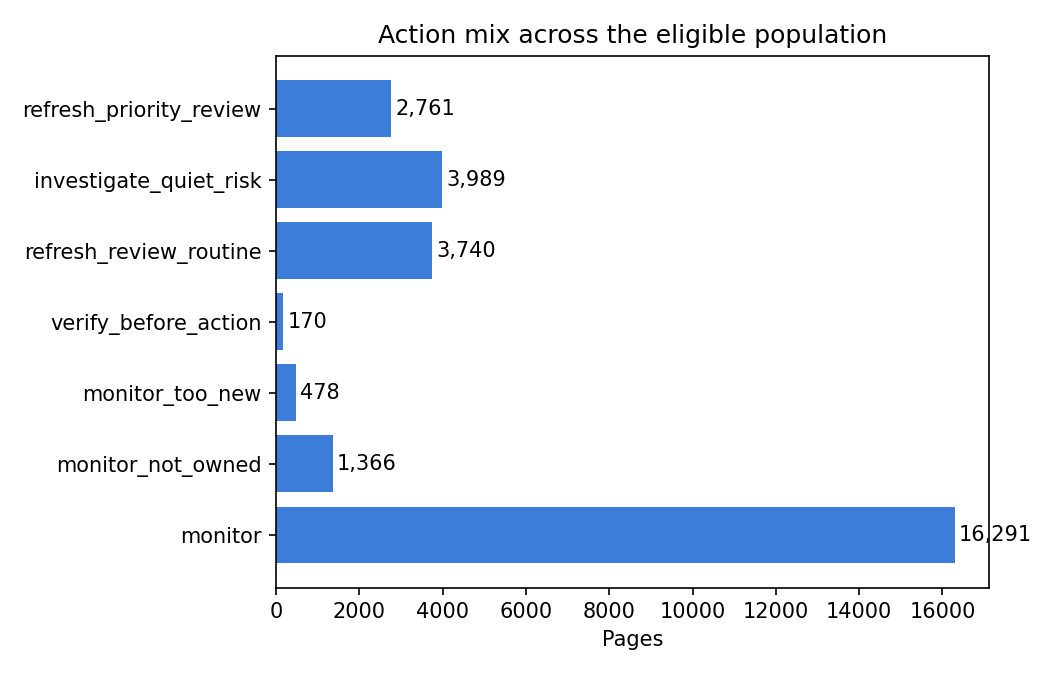

In [6]:
action_mix = pd.Series(m7["action_mix"] if "action_mix" in m7 else m7.get("action_counts", {}))
if len(action_mix) == 0:
    # fall back: the counts are also reproducible directly, no fitting required
    print("action_mix not found under that key -- see work/outputs/w07_playbook_metrics.json directly:")
    print(json.dumps(m7, indent=2)[:1500])
else:
    display(action_mix.sort_values(ascending=False))

display(Image(filename=str(FIG / "w07_action_mix.png")))


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

---

The deployed paper (`docs/index.html`) and the source write-up (`work/capstone_report.md`)
embed exactly these committed artifacts -- nothing is regenerated at deploy time:

| Artifact | Used for |
|---|---|
| `work/outputs/w04_baseline_metrics.json` | baseline rule population + flag counts |
| `work/outputs/w05_model_metrics.json` | leakage check, LR/RF Precision@50 |
| `work/outputs/w06_validation_audit.json` | grouped-vs-naive split comparison, leak-detector check |
| `work/outputs/w07_playbook_metrics.json` | action mix, retrospective audit |
| `work/figures/w07_precision_at_k.png` | Results section, Figure 1 |
| `work/figures/w07_action_mix.png` | Results section, Figure 2 |


In [7]:
# Confirms every artifact the deployed paper links to actually exists in this repo --
# run this before deploying so a broken image/link is caught here, not by a stranger.
required = [
    OUT / "w04_baseline_metrics.json",
    OUT / "w05_model_metrics.json",
    OUT / "w06_validation_audit.json",
    OUT / "w07_playbook_metrics.json",
    FIG / "w07_precision_at_k.png",
    FIG / "w07_action_mix.png",
    Path("docs/index.html"),
    Path("docs/assets/w07_precision_at_k.png"),
    Path("docs/assets/w07_action_mix.png"),
    Path("work/capstone_report.md"),
]
missing = [str(p) for p in required if not p.exists()]
print("All paper artifacts present." if not missing else f"MISSING: {missing}")


All paper artifacts present.


## 8. ML-12 -- closing: demo outline, social cut, employer summary

*The smallest card and the easiest to forget -- so it lives here, in the same notebook.*

---

**5-minute demo outline**
1. (0:00-0:30) The question: which of 28,795 pages should a reviewer open first this cycle?
2. (0:30-1:30) The trap: the obvious rule (`stale_but_visible`) scores *below* the base rate --
   show the Precision@50 chart.
3. (1:30-3:00) The honest fix: client-grouped validation, the leakage catch on
   `impressions_last/prev_30d`, and the 0.86 -> 0.72 split-sensitivity result.
4. (3:00-4:00) The output: the reason-coded queue (`refresh_priority_review`,
   `investigate_quiet_risk`, ...) and one concrete top-ranked page, read aloud with its reason
   code and its "would be wrong if" caveat.
5. (4:00-5:00) The limits, said out loud: cross-sectional, 31 clients, no forward-in-time test
   yet -- decision support, not a causal claim.

**Social post cut (one finding + one chart + one method sentence + link)**

> A "refresh stale pages" rule sounds obviously right -- ours scored *below* random at
> Precision@50. A client-grouped Logistic Regression on the same 28,795-page slice hit 0.72 vs.
> a 0.56 base rate -- and a naive random split would have overstated that by 14 points. Paper:
> [deployed URL] | Repo: github.com/abuhussein1504/flyrank-ml-internship-starter

**Employer 3-sentencer**

> I built a client-grouped, leakage-audited ranking model that prioritizes which content pages
> a review team should look at first, on a 30,000-page pseudonymized export from a real content
> operation (FlyRank). It beat both a transparent rule and random ordering at Precision@50
> (0.72 vs. 0.44 vs. 0.56), and I caught and fixed a label-leakage bug and a split-choice
> inflation (0.86 -> 0.72) before trusting either number. The full pipeline -- data contract,
> baseline, model, validation audit, and a reason-coded action queue -- is reproducible from a
> public repo and written up as a deployed research paper.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled -- markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime -> Run all) -- every code cell
      reads committed receipts (`work/outputs/*.json`, `work/figures/*.png`) or the bundled
      starter CSV, so it reruns in seconds with no external/gated dependency
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` -- then submit your repo URL on the card,
      with the deployed paper URL in `submission/paper_url.txt`. Done.
